In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv('../dataset/creditcard.csv')

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.3f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head()

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


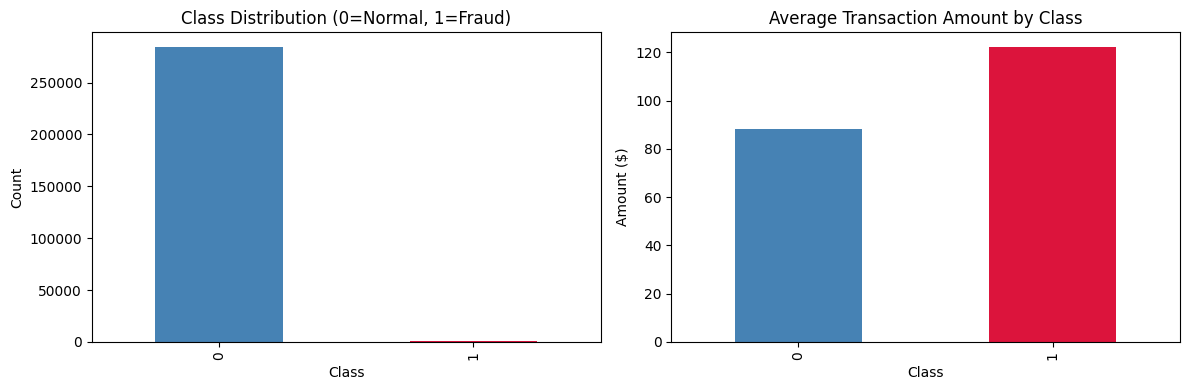

Plot saved


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (0=Normal, 1=Fraud)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# Transaction amount by class
df.groupby('Class')['Amount'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'crimson'])
axes[1].set_title('Average Transaction Amount by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('../dataset/class_distribution.png')
plt.show()
print("Plot saved")

In [20]:
# Scale Amount and Time - only raw features not already PCA transformed
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df = df.drop(['Amount', 'Time'], axis=1)

# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train test split - stratified to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Fraud cases in test: {y_test.sum()}")

Train size: (227845, 30)
Test size: (56962, 30)
Fraud cases in test: 98


In [21]:
print(f"Before SMOTE - Fraud: {y_train.sum()}, Normal: {(y_train==0).sum()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  - Fraud: {y_train_resampled.sum()}, Normal: {(y_train_resampled==0).sum()}")

Before SMOTE - Fraud: 394, Normal: 227451
After SMOTE  - Fraud: 227451, Normal: 227451


In [22]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print("Training complete")

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035746 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0254084
[200]	valid_0's binary_logloss: 0.00937305
[300]	valid_0's binary_logloss: 0.00626586
[400]	valid_0's binary_logloss: 0.00547523
[500]	valid_0's binary_logloss: 0.00524934
Did not meet early stopping. Best iteration is:
[496]	valid_0's binary_logloss: 0.00524733
Training complete


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.75      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



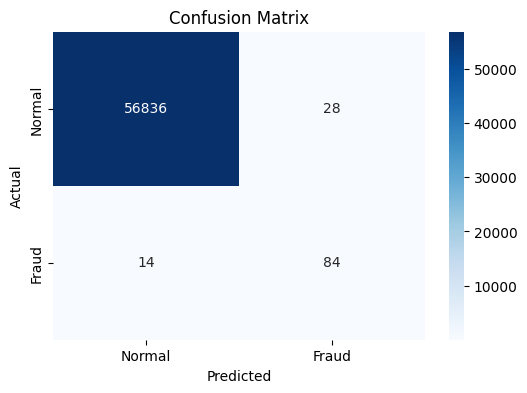


F1 Score (Fraud class): 0.8000


In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../dataset/confusion_matrix.png')
plt.show()

f1 = f1_score(y_test, y_pred)
print(f"\nF1 Score (Fraud class): {f1:.4f}")

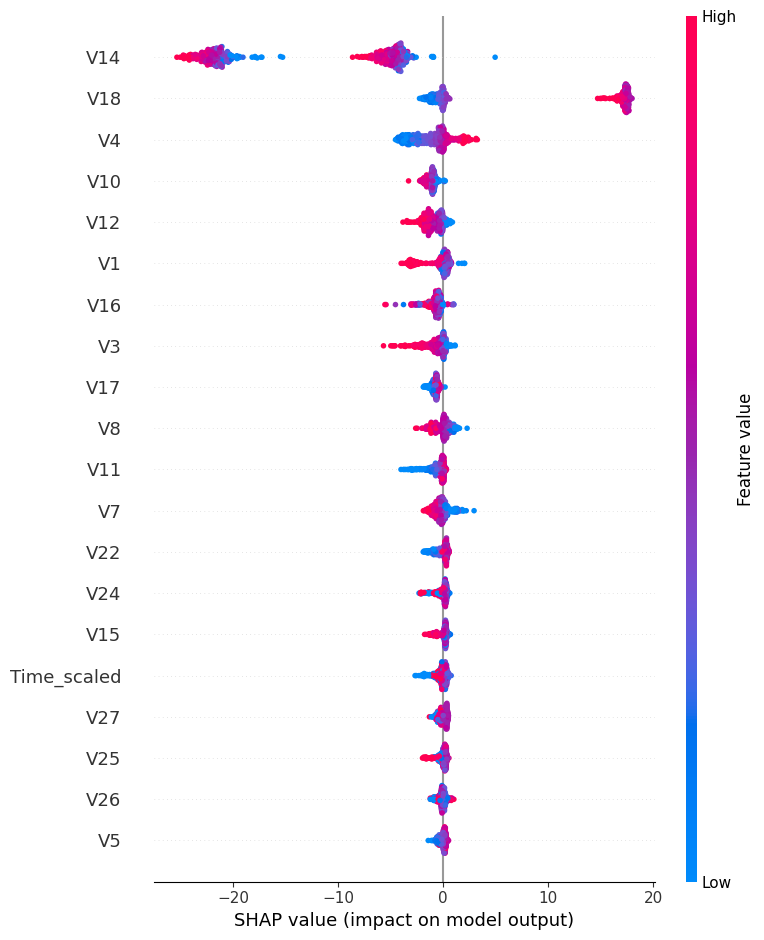

SHAP plot saved


In [24]:
explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    plot_shap_values = shap_values[1]  # index 1 = fraud class
else:
    plot_shap_values = shap_values

plt.figure()
shap.summary_plot(plot_shap_values, X_sample, show=False)
plt.savefig('../dataset/shap_summary.png', bbox_inches='tight')
plt.show()
print("SHAP plot saved")

In [ ]:
import os
os.makedirs('../models', exist_ok=True)

with open('../models/fraud_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved to /models")

Model and scaler saved to /models


In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

# Use SMOTE resampled data like LightGBM - remove scale_pos_weight
xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_pred = xgb_model.predict(X_test)
xgb_f1 = f1_score(y_test, xgb_pred)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Normal', 'Fraud']))
print(f"XGBoost F1 Score (Fraud class): {xgb_f1:.4f}")

[0]	validation_0-aucpr:0.47785
[100]	validation_0-aucpr:0.82341
[200]	validation_0-aucpr:0.83947
[300]	validation_0-aucpr:0.85743
[400]	validation_0-aucpr:0.86378
[499]	validation_0-aucpr:0.86834

XGBoost Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.67      0.87      0.76        98

    accuracy                           1.00     56962
   macro avg       0.83      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

XGBoost F1 Score (Fraud class): 0.7556


In [28]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.0017,  # matches actual fraud ratio in dataset
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)  # unsupervised - train on original imbalanced data, no SMOTE

# Isolation Forest returns -1 for anomalies, 1 for normal
iso_pred_raw = iso_forest.predict(X_test)
iso_pred = [1 if x == -1 else 0 for x in iso_pred_raw]

iso_f1 = f1_score(y_test, iso_pred)

print("Isolation Forest Classification Report:")
print(classification_report(y_test, iso_pred, target_names=['Normal', 'Fraud']))
print(f"Isolation Forest F1 Score (Fraud class): {iso_f1:.4f}")

Isolation Forest Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.25      0.28      0.26        98

    accuracy                           1.00     56962
   macro avg       0.63      0.64      0.63     56962
weighted avg       1.00      1.00      1.00     56962

Isolation Forest F1 Score (Fraud class): 0.2634


           Model  F1 Score (Fraud)              Approach
        LightGBM            0.8000    Supervised + SMOTE
         XGBoost            0.7556 Supervised + SMOTE XG
Isolation Forest            0.2634          Unsupervised


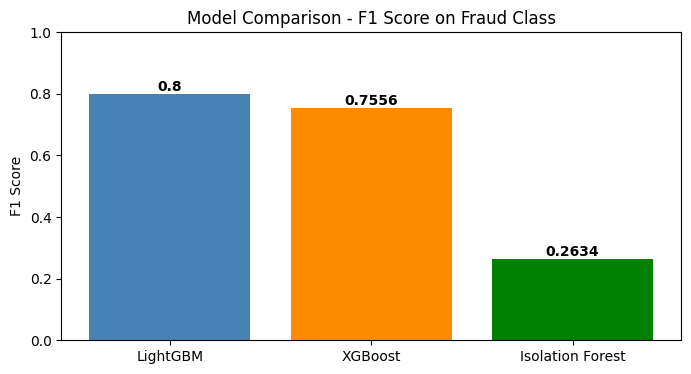

In [ ]:
results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'Isolation Forest'],
    'F1 Score (Fraud)': [
        round(f1_score(y_test, y_pred), 4),
        round(xgb_f1, 4),
        round(iso_f1, 4)
    ],
    'Approach': ['Supervised + SMOTE', 'Supervised + SMOTE XG', 'Unsupervised']
})

print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 4))
colors = ['steelblue', 'darkorange', 'green']
plt.bar(results['Model'], results['F1 Score (Fraud)'], color=colors)
plt.title('Model Comparison - F1 Score on Fraud Class')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for i, v in enumerate(results['F1 Score (Fraud)']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.savefig('../dataset/model_comparison.png')
plt.show()

In [32]:
lgb_tuned = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_tuned.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

tuned_pred = lgb_tuned.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_pred)

print("\nTuned LightGBM Classification Report:")
print(classification_report(y_test, tuned_pred, target_names=['Normal', 'Fraud']))
print(f"Tuned LightGBM F1 Score (Fraud class): {tuned_f1:.4f}")

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.100604
[200]	valid_0's binary_logloss: 0.0279524
[300]	valid_0's binary_logloss: 0.0122313
[400]	valid_0's binary_logloss: 0.00653893
[500]	valid_0's binary_logloss: 0.00465031
[600]	valid_0's binary_logloss: 0.00380265
[700]	valid_0's binary_logloss: 0.00345739
[800]	valid_0's binary_logloss: 0.00332666
[900]	valid_0's binary_logloss: 0.00328069
Early stopping, best iteration is:
[930]	valid_0's binary_logloss: 0.00327352

Tuned LightGBM Classification Repor

           Model  F1 Score (Fraud)                   Approach
 LightGBM (base)            0.8000         Supervised + SMOTE
LightGBM (tuned)            0.8293 Supervised + SMOTE + Tuned
         XGBoost            0.7556         Supervised + SMOTE
Isolation Forest            0.2634               Unsupervised


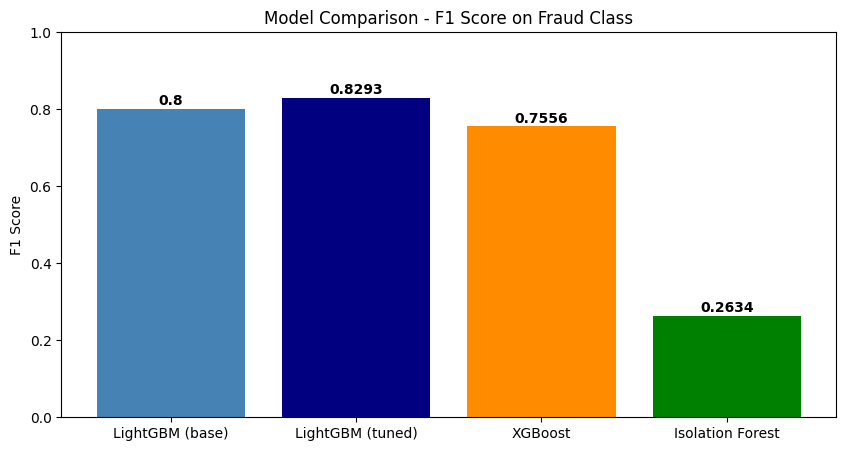

In [33]:
results = pd.DataFrame({
    'Model': ['LightGBM (base)', 'LightGBM (tuned)', 'XGBoost', 'Isolation Forest'],
    'F1 Score (Fraud)': [
        round(f1_score(y_test, y_pred), 4),
        round(tuned_f1, 4),
        round(xgb_f1, 4),
        round(iso_f1, 4)
    ],
    'Approach': [
        'Supervised + SMOTE',
        'Supervised + SMOTE + Tuned',
        'Supervised + SMOTE',
        'Unsupervised'
    ]
})

print(results.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['steelblue', 'navy', 'darkorange', 'green']
bars = plt.bar(results['Model'], results['F1 Score (Fraud)'], color=colors)
plt.title('Model Comparison - F1 Score on Fraud Class')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for bar, v in zip(bars, results['F1 Score (Fraud)']):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             str(v), ha='center', fontweight='bold')
plt.savefig('../dataset/model_comparison.png', bbox_inches='tight')
plt.show()

In [34]:
with open('../models/fraud_model.pkl', 'wb') as f:
    pickle.dump(lgb_tuned, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Tuned model and scaler saved to /models")

Tuned model and scaler saved to /models


In [36]:
import pickle

# Fit separate scalers properly
from sklearn.preprocessing import StandardScaler

amount_scaler = StandardScaler()
time_scaler = StandardScaler()

df_original = pd.read_csv('../dataset/creditcard.csv')
amount_scaler.fit(df_original[['Amount']])
time_scaler.fit(df_original[['Time']])

with open('../models/amount_scaler.pkl', 'wb') as f:
    pickle.dump(amount_scaler, f)

with open('../models/time_scaler.pkl', 'wb') as f:
    pickle.dump(time_scaler, f)

print("Separate scalers saved")
print(f"Amount mean: {amount_scaler.mean_[0]:.4f}, scale: {amount_scaler.scale_[0]:.4f}")
print(f"Time mean: {time_scaler.mean_[0]:.4f}, scale: {time_scaler.scale_[0]:.4f}")

Separate scalers saved
Amount mean: 88.3496, scale: 250.1197
Time mean: 94813.8596, scale: 47488.0626
